# 🧪 实战练手: 倾向性得分匹配 (PSM) 会员干预

> **目标**: 0-1 手写 PSM 代码，评估 "技术支持服务 (Tech Support)" 对 "用户流失 (Churn)" 的因果效应。
> **SOP**: 业务定义 -> 混淆变量识别 -> 计算 PS 分数 -> 匹配 -> 效果评估。

## 📖 核心概念 (SQL 类比)
*   **Selection Bias**: 买了 TechSupport 的人本来就更忠诚 (Tenure 更长)，直接比 Churn Rate 是不公平的。
*   **Propensity Score**: `P(Treatment=1 | X)`。把多维特征压缩成一个概率值。
*   **Matching**: `WHERE abs(PS_Treated - PS_Control) < threshold`。找替身。

---

In [1]:
# 0. 函数加油站 (Function Cheat Sheet)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import NearestNeighbors

# -------------------------------------------------------
# 1. LogisticRegression().fit(X, y).predict_proba(X)
#    解释: 用于计算 Propensity Score (即成为干预组的概率)
# -------------------------------------------------------
# 2. NearestNeighbors(n_neighbors=1).fit(X)
#    解释: 用于在 Control 组中找到最像 Treated 的那个样本
# -------------------------------------------------------

## 1. 数据准备 (Data Prep)
这里我们模拟电信客户数据。
*   **Treatment**: `has_tech_support` (1=买了, 0=没买)
*   **Outcome**: `churn` (1=流失, 0=留存)
*   **Confounder**: `tenure` (在网时长), `monthly_charges` (月费)
*   **Hidden Truth**: TechSupport 能让流失率下降 10% (Absolute Reduction)。

In [2]:
# 🏭 数据生成器 (无需修改，运行即可)
def generate_psm_data(n_samples=1000):
    np.random.seed(42)
    
    # 1. 生成混淆变量 (Confounders)
    # Tenure: 0-72 months
    tenure = np.random.randint(1, 73, n_samples)
    # Monthly Charges: 20-120
    monthly_charges = np.random.normal(70, 30, n_samples)
    monthly_charges = np.clip(monthly_charges, 20, 120)
    
    # 2. 生成干预分配机制 (Treatment Assignment)
    # Tenure 越长，越容易买 TechSupport (Selection Bias)
    ps_logit = -2 + 0.05 * tenure + 0.01 * monthly_charges
    ps_prob = 1 / (1 + np.exp(-ps_logit))
    has_tech_support = np.random.binomial(1, ps_prob)
    
    # 3. 生成结果 (Outcome)
    # 基础流失概率: Tenure 越短越容易流失
    churn_logit = 1 - 0.08 * tenure + 0.005 * monthly_charges 
    # 干预效应: 买了 TechSupport，流失概率 logit 显著下降
    churn_logit += -1.5 * has_tech_support 
    
    churn_prob = 1 / (1 + np.exp(-churn_logit))
    churn = np.random.binomial(1, churn_prob)
    
    df = pd.DataFrame({
        'tenure': tenure,
        'monthly_charges': monthly_charges,
        'has_tech_support': has_tech_support,
        'churn': churn
    })
    return df

df = generate_psm_data()
print("Naive Churn Comparison:")
print(df.groupby('has_tech_support')['churn'].mean())
# 你会发现买了服务的人流失率极低，但这不全是因为服务，还因为他们本来即是老客户

Naive Churn Comparison:
has_tech_support
0    0.389744
1    0.065574
Name: churn, dtype: float64


## 2. 挑战 Level 1: 计算 Propensity Score
**任务**: 使用 `LogisticRegression` 预测每个用户购买 `has_tech_support` 的概率。
*   Feature: `tenure`, `monthly_charges`
*   Target: `has_tech_support`
*   Output: 把预测概率存入 `df['ps_score']`

In [ ]:
# [YOUR CODE HERE]


In [3]:
df.head()

,tenure,monthly_charges,has_tech_support,churn
0,52,62.295489,1,0
1,15,100.728597,1,1
2,72,21.324291,1,0
3,61,80.229651,1,0
4,21,70.767140,1,0


In [ ]:
from sklearn.linear_model import LogisticRegression
x = df[['tenure','monthly_charges']]
y = df['has_tech_support']
model = LogisticRegression()
model.fit(x,y)

df['ps_score'] = model.predict_proba(x)[:,1]
df
# model.predict_proba(x)

./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
./Library/Python/3.9/lib/python/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


array([[0.23502842, 0.76497158],
       [0.51701826, 0.48298174],
       [0.16504144, 0.83495856],
       ...,
       [0.12173297, 0.87826703],
       [0.39157661, 0.60842339],
       [0.21014496, 0.78985504]])

## 3. 挑战 Level 2: 进行匹配 (Matching)
**任务**: 使用 `NearestNeighbors` 为每个 Treated 用户找一个最近的 Control 用户。
*   思路: 
    1. 分割 `treated_df` 和 `control_df`。
    2. 用 `NearestNeighbors` 在 `control_df[['ps_score']]` 上训练。
    3. 找 `treated_df[['ps_score']]` 的邻居。
    4. 构建 `matched_control_df`。

In [8]:
# [YOUR CODE HERE]
# 提示代码
from sklearn.neighbors import NearestNeighbors

# 1. 拆分数据
treated_df = df[df['has_tech_support'] == 1]
control_df = df[df['has_tech_support'] == 0]

# 2. 训练匹配模型 (在 Control 组里找)
nn = NearestNeighbors(n_neighbors=1)
nn.fit(control_df[['ps_score']]) 

# 3. 为 Treated 找邻居
distances, indices = nn.kneighbors(treated_df[['ps_score']])

# 4. 提取匹配到的 Control 用户
# indices 返回的是 control_df 的行号(iloc)，不是 index
matched_control_df = control_df.iloc[indices.flatten()] 

matched_control_df

,tenure,monthly_charges,has_tech_support,churn,ps_score
619,54,54.327936,0,0,0.764850
322,25,61.050895,0,0,0.482602
932,57,80.728728,0,1,0.835094
508,67,56.151112,0,1,0.857582
465,23,63.028027,0,0,0.465492
...,...,...,...,...,...
87,5,48.871626,0,1,0.244974
933,26,44.880428,0,0,0.447457
647,34,51.952490,0,0,0.558950
847,67,69.525409,0,0,0.875456


## 4. 挑战 Level 3: 假设检验与评估
**任务**: 
1.  **Balance Check**: 检查匹配后，两组的 `tenure` 均值是否接近了？(之前肯定差很多)
2.  **ATE Calculation**: 计算 (Treated Churn Mean) - (Matched Control Churn Mean)。

In [ ]:
# [YOUR CODE HERE]
# 1. Balance Check

# 2. Effect Calculation


In [9]:
# Level 3 代码提示
ate = treated_df['churn'].mean() - matched_control_df['churn'].mean()
print(f"PSM 估算的干预效应: {ate:.2%}")


PSM 估算的干预效应: -13.28%


In [10]:
# 1. 看看配对前 (原始数据)
print("配对前 Tenure 差异:")
print(df.groupby('has_tech_support')['tenure'].mean())

# 2. 看看配对后 (Treated vs Matched Control)
print("\n配对后 Tenure 差异:")
print(f"Treated (原版): {treated_df['tenure'].mean():.2f}")
print(f"Control (替身): {matched_control_df['tenure'].mean():.2f}")

# 3. 计算 ATE
ate = treated_df['churn'].mean() - matched_control_df['churn'].mean()
print(f"\n最终结论: ATE = {ate:.2%}")


配对前 Tenure 差异:
has_tech_support
0    25.120513
1    42.760656
Name: tenure, dtype: float64

配对后 Tenure 差异:
Treated (原版): 42.76
Control (替身): 43.12

最终结论: ATE = -13.28%


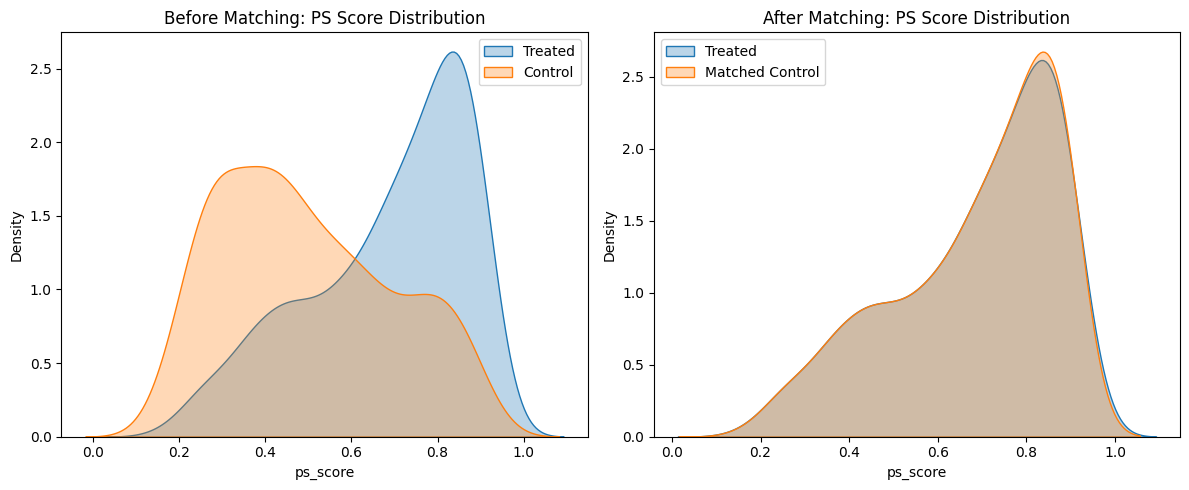

In [11]:
# -------------------------------------------------------
# 进阶验证：画出 Propensity Score 分布对比图
# -------------------------------------------------------
plt.figure(figsize=(12, 5))

# 1. 配对前 (Before Matching)
plt.subplot(1, 2, 1)
sns.kdeplot(df[df['has_tech_support']==1]['ps_score'], label='Treated', fill=True, alpha=0.3)
sns.kdeplot(df[df['has_tech_support']==0]['ps_score'], label='Control', fill=True, alpha=0.3)
plt.title("Before Matching: PS Score Distribution")
plt.legend()

# 2. 配对后 (After Matching)
plt.subplot(1, 2, 2)
sns.kdeplot(treated_df['ps_score'], label='Treated', fill=True, alpha=0.3)
sns.kdeplot(matched_control_df['ps_score'], label='Matched Control', fill=True, alpha=0.3)
plt.title("After Matching: PS Score Distribution")
plt.legend()

plt.tight_layout()
plt.show()


## 5. 参考答案 (Reference)


In [ ]:
# Level 1
lr = LogisticRegression()
X = df[['tenure', 'monthly_charges']]
y = df['has_tech_support']
lr.fit(X, y)
df['ps_score'] = lr.predict_proba(X)[:, 1]

# Level 2
treated = df[df['has_tech_support'] == 1]
control = df[df['has_tech_support'] == 0]

nn = NearestNeighbors(n_neighbors=1)
nn.fit(control[['ps_score']])
distances, indices = nn.kneighbors(treated[['ps_score']])

matched_control = control.iloc[indices.flatten()]

# Level 3
print("Balance Check (Tenure):")
print(f"Treated: {treated['tenure'].mean():.2f}")
print(f"Matched Control: {matched_control['tenure'].mean():.2f}")

ate = treated['churn'].mean() - matched_control['churn'].mean()
print(f"\nEstimated Causal Effect (ATE): {ate:.2%}")
# 真实的效应应该是负数 (降低流失)